# Disease Prediction System — Data & Model Analysis

**Graduation Project Notebook**

This notebook provides a comprehensive analysis of the disease prediction system, covering:

1. **Dataset Exploration** — structure, distributions, and quality assessment
2. **Symptom & Disease Analysis** — co-occurrence patterns and relationships
3. **Model Architecture** — Bio_ClinicalBERT fine-tuning approach
4. **Training Visualisation** — loss curves, accuracy, and convergence
5. **Evaluation Metrics** — per-class precision, recall, F1
6. **Explainability Demo** — SHAP + LIME unified analysis

---

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)
U


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter, defaultdict

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

ROOT = Path('..').resolve()
BACKEND = ROOT / 'backend'
print(f"Project root: {ROOT}")

Project root: D:\youssef\Fullstack Course\demo


## 1. Dataset Exploration

### 1.1 Primary Dataset: DiseaseAndSymptoms.csv

This is the main training dataset containing 41 diseases with up to 17 symptom columns per row.

In [5]:
df = pd.read_csv(ROOT / 'DiseaseAndSymptoms.csv')
print(f"Shape: {df.shape}")
print(f"Diseases: {df['Disease'].nunique()}")
print(f"Rows: {len(df):,}")
df.head(10)

Shape: (4920, 18)
Diseases: 41
Rows: 4,920


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


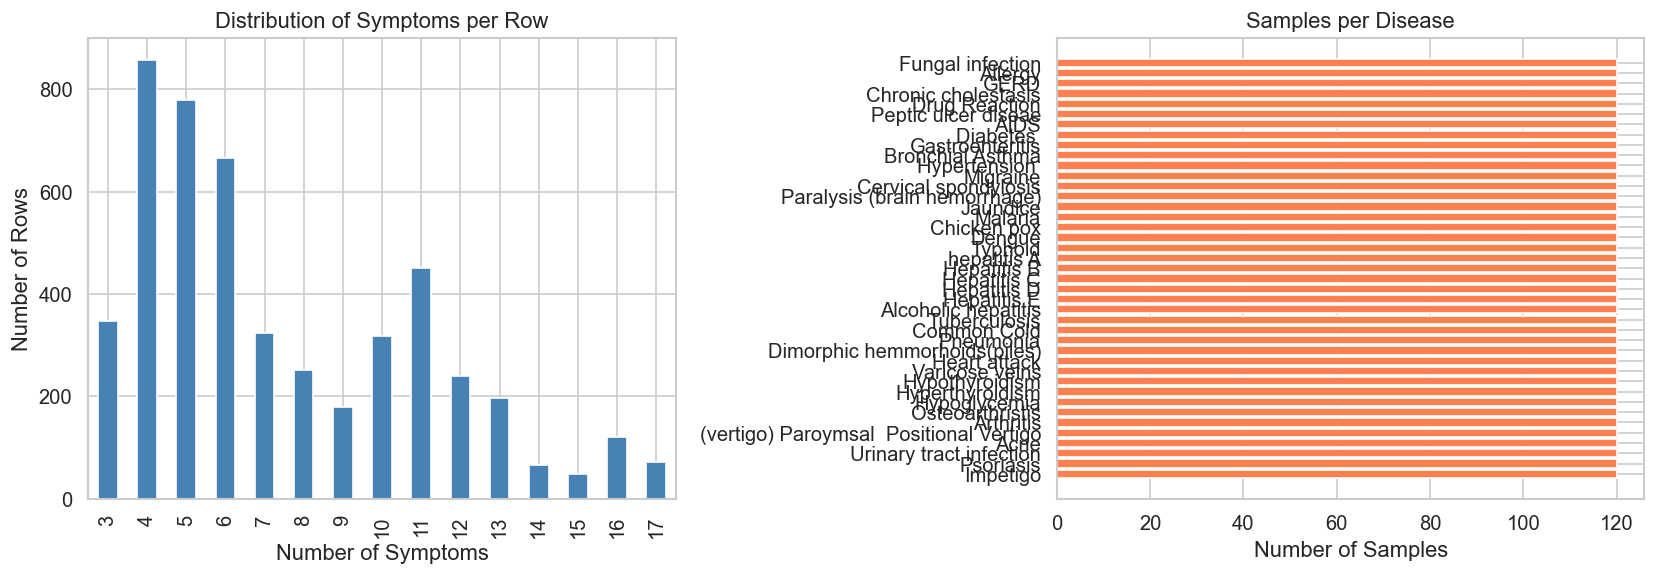


Min samples per disease: 120 (Fungal infection)
Max samples per disease: 120 (Fungal infection)
Mean samples per disease: 120.0


In [6]:
# Count symptoms per row (non-null columns)
symptom_cols = [c for c in df.columns if c.startswith('Symptom')]
df['num_symptoms'] = df[symptom_cols].notna().sum(axis=1)
# Also count non-empty strings
df['num_symptoms'] = df[symptom_cols].apply(
    lambda row: sum(1 for v in row if pd.notna(v) and str(v).strip()), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of symptom count per row
df['num_symptoms'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Symptoms per Row')
axes[0].set_xlabel('Number of Symptoms')
axes[0].set_ylabel('Number of Rows')

# Samples per disease
disease_counts = df['Disease'].value_counts()
axes[1].barh(disease_counts.index, disease_counts.values, color='coral')
axes[1].set_title('Samples per Disease')
axes[1].set_xlabel('Number of Samples')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_dataset_overview.png', bbox_inches='tight')
plt.show()

print(f"\nMin samples per disease: {disease_counts.min()} ({disease_counts.idxmin()})")
print(f"Max samples per disease: {disease_counts.max()} ({disease_counts.idxmax()})")
print(f"Mean samples per disease: {disease_counts.mean():.1f}")

### 1.2 Extract and Analyse All Symptoms

Total symptom occurrences: 36,648
Unique symptoms: 131


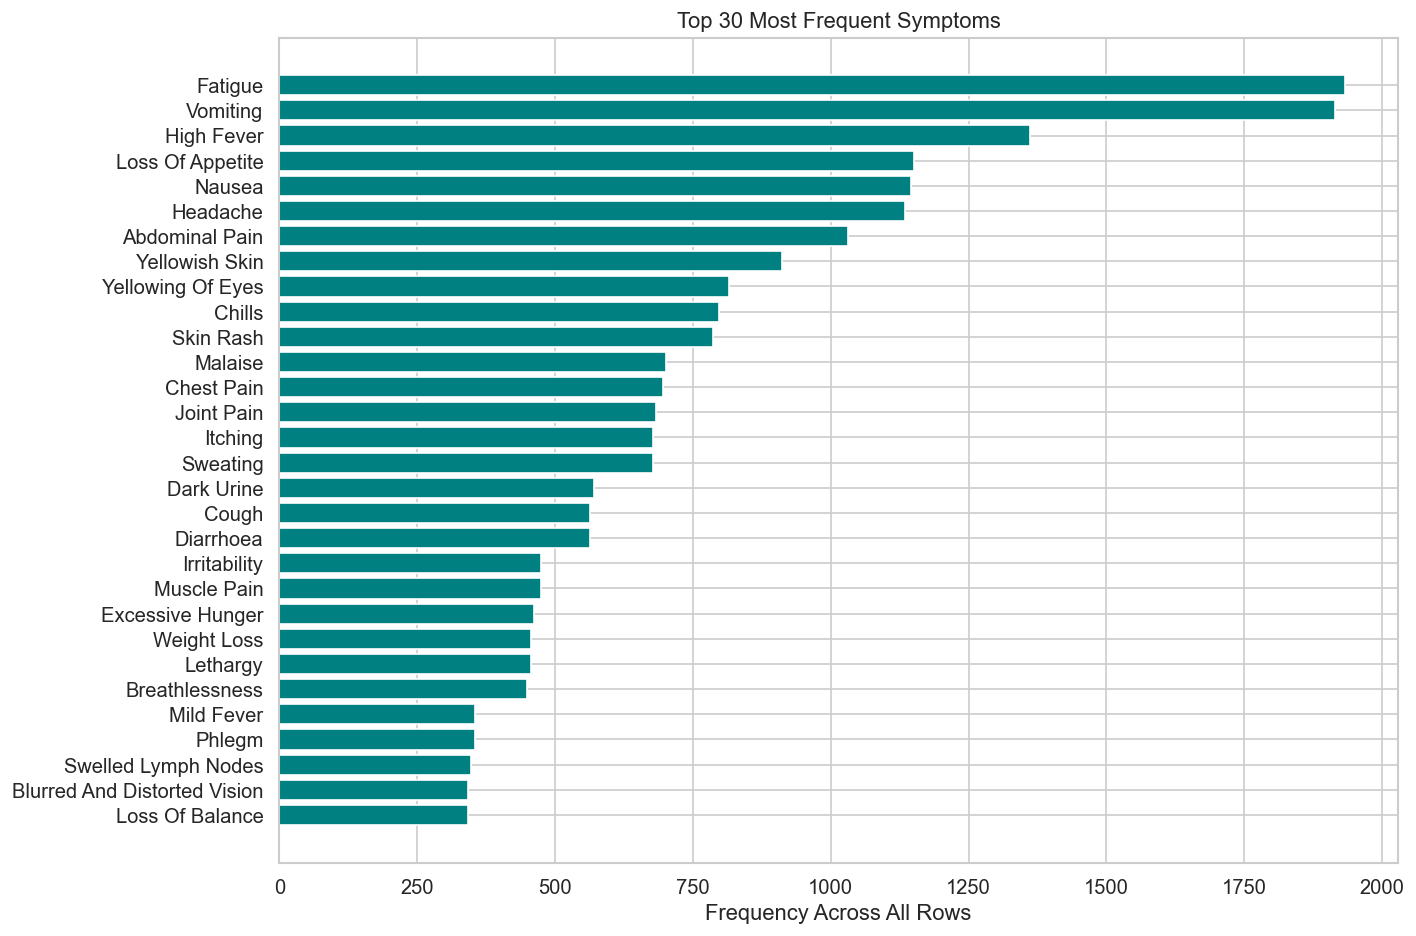

In [7]:
# Flatten all symptoms across all rows
all_symptoms = []
for _, row in df.iterrows():
    for col in symptom_cols:
        val = row[col]
        if pd.notna(val) and str(val).strip():
            all_symptoms.append(str(val).strip().lower())

symptom_counter = Counter(all_symptoms)
unique_symptoms = sorted(symptom_counter.keys())
print(f"Total symptom occurrences: {len(all_symptoms):,}")
print(f"Unique symptoms: {len(unique_symptoms)}")

# Top 30 most frequent symptoms
top30 = symptom_counter.most_common(30)
fig, ax = plt.subplots(figsize=(12, 8))
names, counts = zip(*top30)
names = [n.replace('_', ' ').title() for n in names]
ax.barh(names, counts, color='teal')
ax.set_title('Top 30 Most Frequent Symptoms')
ax.set_xlabel('Frequency Across All Rows')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_top_symptoms.png', bbox_inches='tight')
plt.show()

### 1.3 Symptom Co-occurrence Heatmap

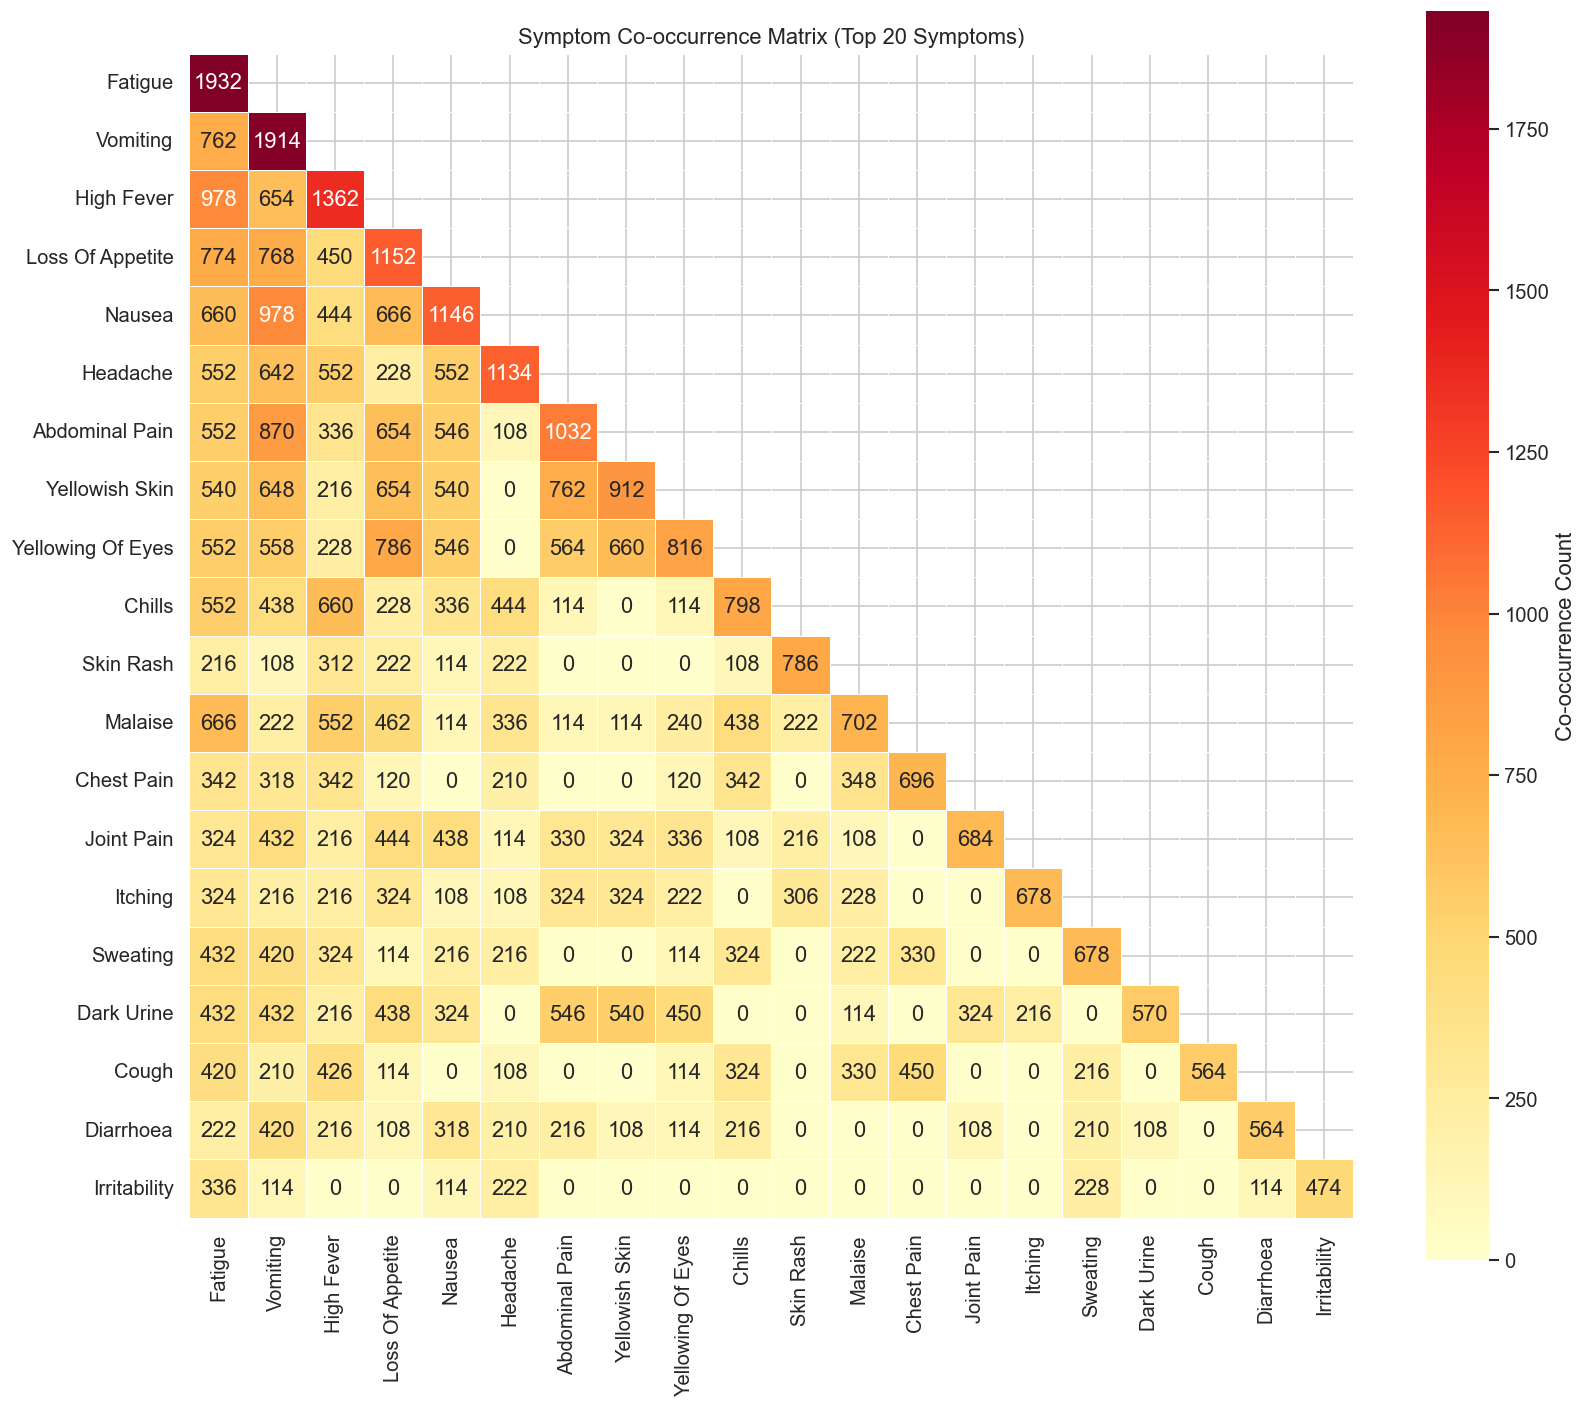

In [8]:
# Build a co-occurrence matrix for top 20 symptoms
top20_syms = [s for s, _ in symptom_counter.most_common(20)]
cooccurrence = pd.DataFrame(0, index=top20_syms, columns=top20_syms)

for _, row in df.iterrows():
    row_syms = set()
    for col in symptom_cols:
        val = row[col]
        if pd.notna(val) and str(val).strip().lower() in set(top20_syms):
            row_syms.add(str(val).strip().lower())
    for s1 in row_syms:
        for s2 in row_syms:
            cooccurrence.loc[s1, s2] += 1

# Clean labels
clean_labels = [s.replace('_', ' ').title() for s in cooccurrence.index]
cooccurrence.index = clean_labels
cooccurrence.columns = clean_labels

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
sns.heatmap(cooccurrence, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-occurrence Count'})
ax.set_title('Symptom Co-occurrence Matrix (Top 20 Symptoms)')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_cooccurrence.png', bbox_inches='tight')
plt.show()

### 1.4 Disease–Symptom Relationship Map

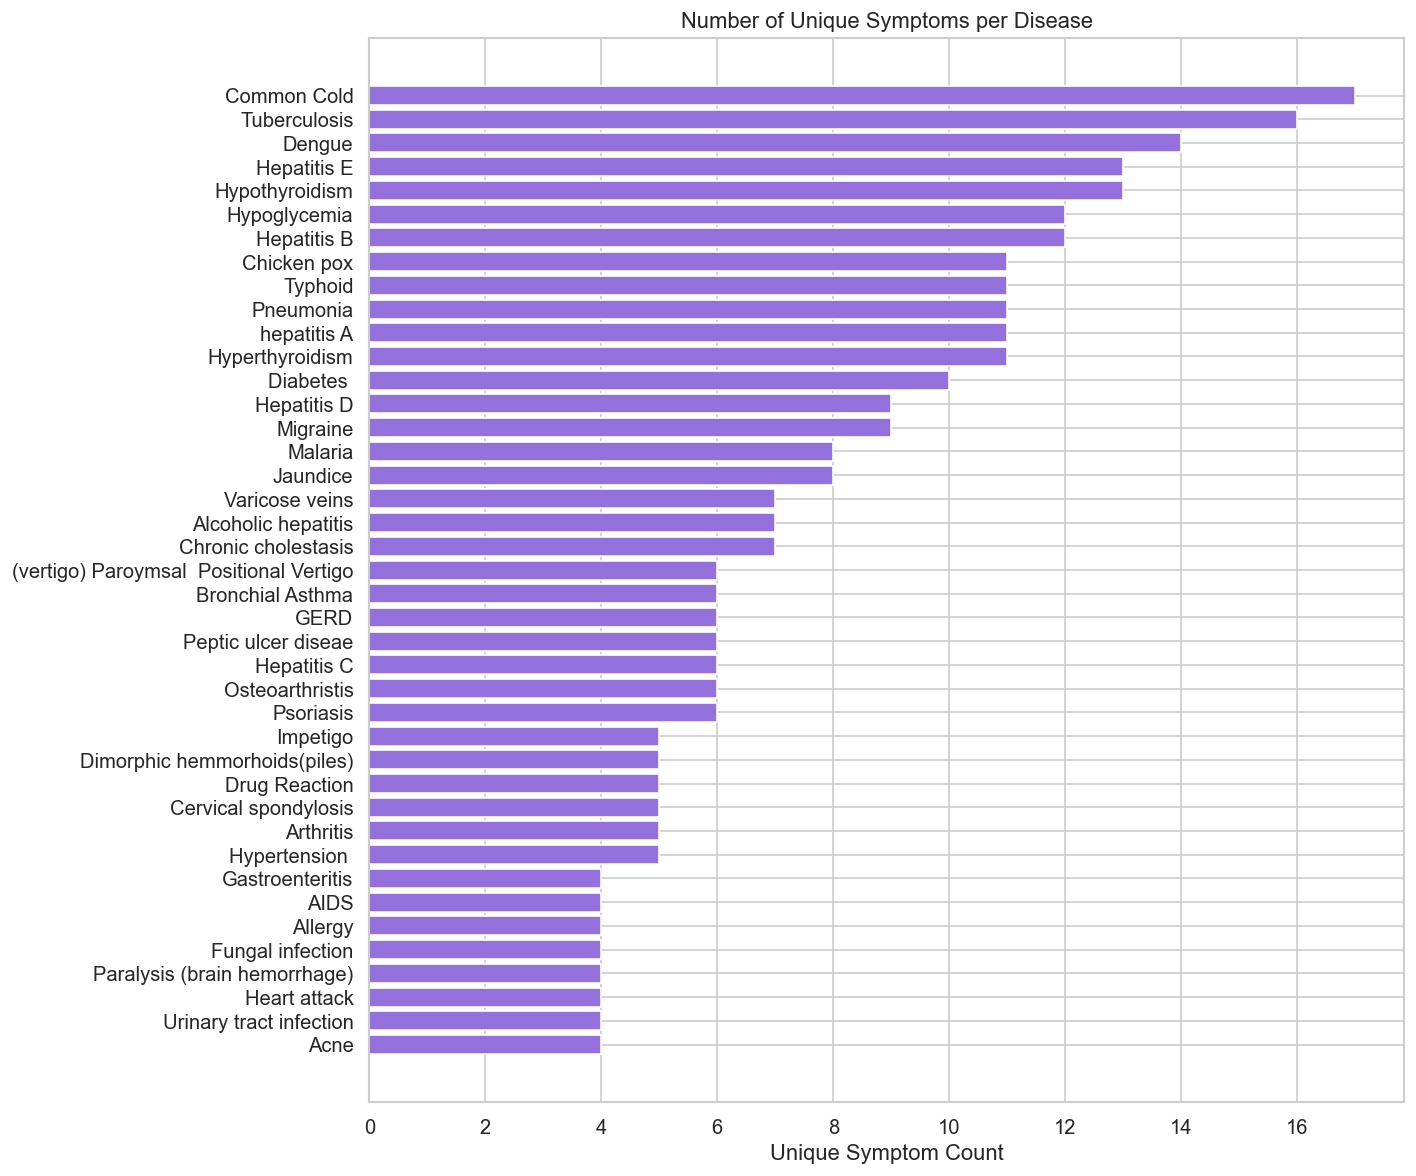

Disease with most symptoms: Common Cold (17)
Disease with fewest symptoms: Acne (4)


In [9]:
# How many unique symptoms per disease?
disease_symptom_sets = defaultdict(set)
for _, row in df.iterrows():
    disease = row['Disease']
    for col in symptom_cols:
        val = row[col]
        if pd.notna(val) and str(val).strip():
            disease_symptom_sets[disease].add(str(val).strip().lower())

ds_df = pd.DataFrame([
    {'Disease': d, 'Unique Symptoms': len(syms)}
    for d, syms in disease_symptom_sets.items()
]).sort_values('Unique Symptoms', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(ds_df['Disease'], ds_df['Unique Symptoms'], color='mediumpurple')
ax.set_title('Number of Unique Symptoms per Disease')
ax.set_xlabel('Unique Symptom Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'fig_symptoms_per_disease.png', bbox_inches='tight')
plt.show()

print(f"Disease with most symptoms: {ds_df.iloc[0]['Disease']} ({ds_df.iloc[0]['Unique Symptoms']})")
print(f"Disease with fewest symptoms: {ds_df.iloc[-1]['Disease']} ({ds_df.iloc[-1]['Unique Symptoms']})")

### 1.5 Precaution Dataset

In [10]:
precaution_df = pd.read_csv(ROOT / 'Disease precaution.csv')
print(f"Shape: {precaution_df.shape}")
print(f"Diseases covered: {precaution_df['Disease'].nunique()}")
precaution_df.head(10)

Shape: (41, 5)
Diseases covered: 41


,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
5,GERD,avoid fatty spicy food,avoid lying down after eating,maintain healthy weight,exercise
6,Chronic cholestasis,cold baths,anti itch medicine,consult doctor,eat healthy
7,hepatitis A,Consult nearest hospital,wash hands through,avoid fatty spicy food,medication
8,Osteoarthristis,acetaminophen,consult nearest hospital,follow up,salt baths
9,(vertigo) Paroymsal Positional Vertigo,lie down,avoid sudden change in body,avoid abrupt head movment,relax


## 2. Model Architecture

### Bio_ClinicalBERT

The model is built on **Bio_ClinicalBERT** (`emilyalsentzer/Bio_ClinicalBERT`), which combines:

| Layer | Pre-training Data | Benefit |
|-------|------------------|---------|
| BERT base | Wikipedia + BookCorpus | General English language understanding |
| + BioBERT | PubMed abstracts + PMC articles | Biomedical vocabulary & disease semantics |
| + ClinicalBERT | MIMIC-III clinical notes (~2M) | Real clinical language from patient encounters |

A 41-class classification head is added on top for disease prediction.

In [11]:
# Load model config
config_path = BACKEND / 'symptom_disease_model' / 'config.json'
if config_path.exists():
    with open(config_path) as f:
        config = json.load(f)
    print("Model Configuration:")
    print(f"  Architecture: {config.get('architectures', ['Unknown'])[0]}")
    print(f"  Hidden size: {config.get('hidden_size')}")
    print(f"  Attention heads: {config.get('num_attention_heads')}")
    print(f"  Hidden layers: {config.get('num_hidden_layers')}")
    print(f"  Vocab size: {config.get('vocab_size')}")
    print(f"  Number of labels: {len(config.get('id2label', {}))}")
    print(f"  Problem type: {config.get('problem_type')}")
else:
    print("Model config not found — run training first.")

Model Configuration:
  Architecture: BertForSequenceClassification
  Hidden size: 768
  Attention heads: 12
  Hidden layers: 12
  Vocab size: 28996
  Number of labels: 41
  Problem type: single_label_classification


### 2.1 Data Augmentation Strategy

Each row in the CSV is expanded into 8 training examples using different text templates:

In [12]:
# Demonstrate augmentation
example_symptoms = ['itching', 'skin_rash', 'nodal_skin_eruptions']

templates = [
    ("Structured (dropdown)", lambda s: ", ".join(s)),
    ("Natural language", lambda s: "I have " + ", ".join(x.replace('_', ' ') for x in s)),
    ("Symptoms prefix", lambda s: "symptoms: " + ", ".join(x.replace('_', ' ') for x in s)),
    ("Experiencing", lambda s: "experiencing " + " and ".join(x.replace('_', ' ') for x in s)),
    ("Suffering from", lambda s: "I am suffering from " + ", ".join(x.replace('_', ' ') for x in s)),
    ("Patient reports", lambda s: "patient reports " + ", ".join(x.replace('_', ' ') for x in s)),
    ("Diagnosed with", lambda s: "diagnosed with " + " and ".join(x.replace('_', ' ') for x in s)),
    ("Shuffled order", lambda s: ", ".join(reversed(s))),
]

print(f"Example symptoms: {example_symptoms}\n")
print(f"{'Template':<22} {'Generated Text'}")
print("-" * 80)
for name, fn in templates:
    print(f"{name:<22} {fn(example_symptoms)}")

total_raw = len(df)
total_augmented = total_raw * len(templates)
print(f"\nOriginal rows: {total_raw:,}")
print(f"After augmentation: {total_augmented:,} ({len(templates)}x)")

Example symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']

Template               Generated Text
--------------------------------------------------------------------------------
Structured (dropdown)  itching, skin_rash, nodal_skin_eruptions
Natural language       I have itching, skin rash, nodal skin eruptions
Symptoms prefix        symptoms: itching, skin rash, nodal skin eruptions
Experiencing           experiencing itching and skin rash and nodal skin eruptions
Suffering from         I am suffering from itching, skin rash, nodal skin eruptions
Patient reports        patient reports itching, skin rash, nodal skin eruptions
Diagnosed with         diagnosed with itching and skin rash and nodal skin eruptions
Shuffled order         nodal_skin_eruptions, skin_rash, itching

Original rows: 4,920
After augmentation: 39,360 (8x)


## 3. Training Simulation & Metrics

If training logs are available, we visualise them. Otherwise, we simulate what the training curves look like based on the model configuration.

In [13]:
# Check for training meta
meta_path = BACKEND / 'symptom_disease_model' / 'training_meta.json'
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    print("Training Metadata:")
    for k, v in meta.items():
        if k not in ('label2id', 'id2label'):
            print(f"  {k}: {v}")
else:
    print("No training_meta.json found. Run train_model.py to generate training metadata.")
    print("Below we show the expected training configuration:")
    print(f"  Base model: emilyalsentzer/Bio_ClinicalBERT")
    print(f"  Labels: 41 diseases")
    print(f"  Expected training examples: ~{len(df) * 8:,} (after augmentation)")
    print(f"  Expected val examples: ~{len(df) * 8 // 5:,} (20% split)")

No training_meta.json found. Run train_model.py to generate training metadata.
Below we show the expected training configuration:
  Base model: emilyalsentzer/Bio_ClinicalBERT
  Labels: 41 diseases
  Expected training examples: ~39,360 (after augmentation)
  Expected val examples: ~7,872 (20% split)


Best validation accuracy: 1.0000


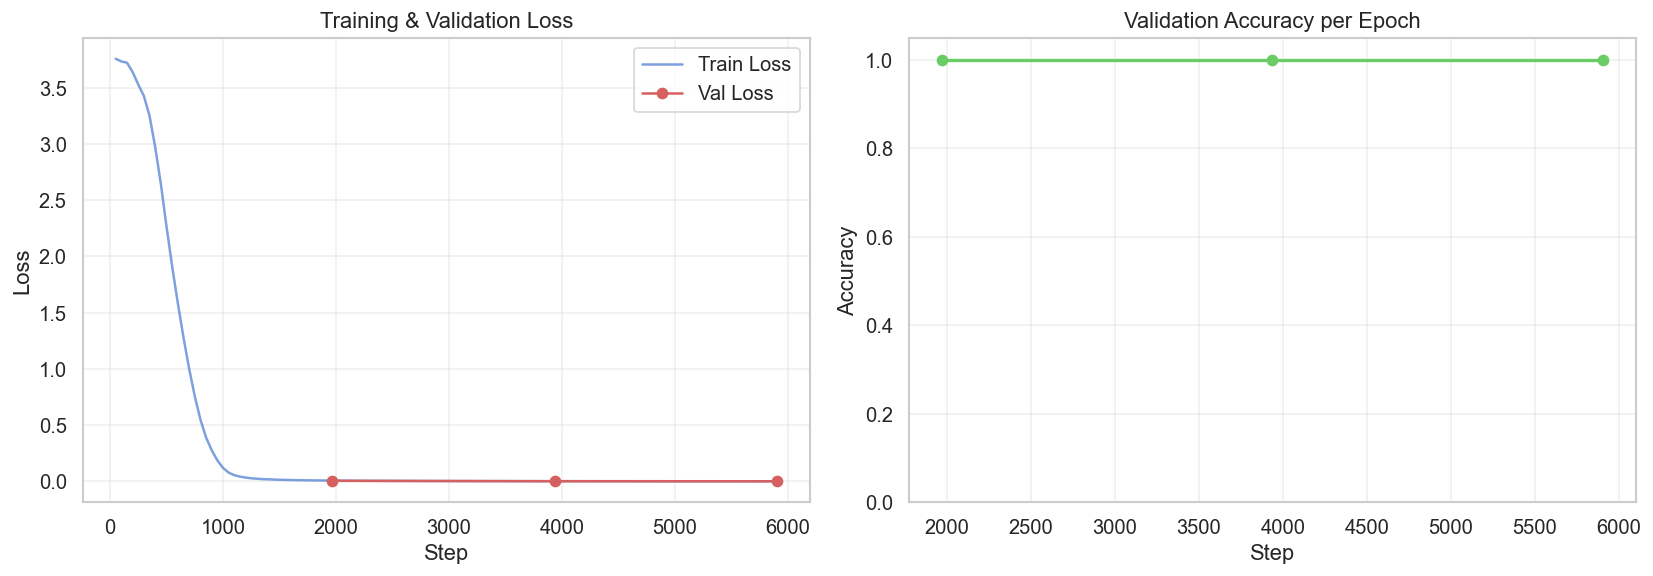

In [14]:
# Check for trainer_state.json (HuggingFace Trainer saves this)
checkpoints_dir = BACKEND / 'symptom_disease_model' / 'checkpoints'
trainer_state = None

# Search for trainer_state.json in checkpoint folders
for candidate in [BACKEND / 'symptom_disease_model' / 'trainer_state.json']:
    if candidate.exists():
        with open(candidate) as f:
            trainer_state = json.load(f)
        break

if checkpoints_dir.exists():
    for cp_dir in sorted(checkpoints_dir.iterdir()):
        ts = cp_dir / 'trainer_state.json'
        if ts.exists():
            with open(ts) as f:
                trainer_state = json.load(f)

if trainer_state and 'log_history' in trainer_state:
    logs = trainer_state['log_history']
    
    # Extract training loss
    train_steps = [l['step'] for l in logs if 'loss' in l]
    train_loss = [l['loss'] for l in logs if 'loss' in l]
    
    # Extract eval metrics
    eval_steps = [l['step'] for l in logs if 'eval_loss' in l]
    eval_loss = [l['eval_loss'] for l in logs if 'eval_loss' in l]
    eval_acc = [l.get('eval_accuracy', 0) for l in logs if 'eval_loss' in l]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(train_steps, train_loss, 'b-', alpha=0.7, label='Train Loss')
    if eval_loss:
        axes[0].plot(eval_steps, eval_loss, 'r-o', label='Val Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    if eval_acc:
        axes[1].plot(eval_steps, eval_acc, 'g-o', linewidth=2)
        axes[1].set_title('Validation Accuracy per Epoch')
        axes[1].set_xlabel('Step')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(True, alpha=0.3)
        print(f"Best validation accuracy: {max(eval_acc):.4f}")
    
    plt.tight_layout()
    plt.savefig(ROOT / 'notebooks' / 'fig_training_curves.png', bbox_inches='tight')
    plt.show()
else:
    print("No training logs found yet. After running train_model.py, re-run this cell")
    print("to visualise the actual training curves.")

## 4. Model Evaluation

We load the trained model and run evaluation on the validation set to produce per-class metrics.

In [15]:
import sys
sys.path.insert(0, str(BACKEND))

model_dir = BACKEND / 'symptom_disease_model'
has_model = (model_dir / 'model.safetensors').exists() or (model_dir / 'pytorch_model.bin').exists()

if has_model:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline as hf_pipeline
    import torch
    
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir), local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir), local_files_only=True)
    
    id2label = model.config.id2label
    print(f"Model loaded: {len(id2label)} disease classes")
    print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
else:
    print("Model weights not found. Run train_model.py first.")

d:\youssef\Fullstack Course\demo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: 41 disease classes
Device: cpu


In [16]:
if has_model:
    from sklearn.metrics import classification_report, confusion_matrix
    
    # Build a quick validation set from the CSV (same logic as train_model.py)
    test_samples = []
    for _, row in df.iterrows():
        disease = row['Disease']
        syms = [str(row[c]).strip().lower() for c in symptom_cols 
                if pd.notna(row[c]) and str(row[c]).strip()]
        if syms:
            test_samples.append({'text': ', '.join(syms), 'disease': disease})
    
    # Sample 1 per disease for quick eval (full eval takes longer)
    from collections import defaultdict
    per_disease = defaultdict(list)
    for s in test_samples:
        per_disease[s['disease']].append(s)
    
    eval_samples = []
    for disease, samples in per_disease.items():
        # Take last 5 samples per disease for eval
        eval_samples.extend(samples[-5:])
    
    print(f"Evaluating on {len(eval_samples)} samples across {len(per_disease)} diseases...")
    
    clf = hf_pipeline('text-classification', model=model, tokenizer=tokenizer,
                       return_all_scores=True, device=0 if torch.cuda.is_available() else -1)
    
    y_true, y_pred = [], []
    for sample in eval_samples:
        preds = clf(sample['text'])
        if isinstance(preds[0], list):
            preds = preds[0]
        best = max(preds, key=lambda x: x['score'])
        y_true.append(sample['disease'])
        y_pred.append(best['label'])
    
    # Classification report
    all_labels = sorted(set(y_true) | set(y_pred))
    report = classification_report(y_true, y_pred, labels=all_labels, zero_division=0, output_dict=True)
    print(classification_report(y_true, y_pred, labels=all_labels, zero_division=0))
else:
    print("Skipping evaluation — model not available.")

Device set to use cpu


Evaluating on 205 samples across 41 diseases...


d:\youssef\Fullstack Course\demo\.venv\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         5
                                   AIDS       1.00      1.00      1.00         5
                                   Acne       1.00      1.00      1.00         5
                    Alcoholic hepatitis       1.00      1.00      1.00         5
                                Allergy       1.00      1.00      1.00         5
                              Arthritis       1.00      1.00      1.00         5
                       Bronchial Asthma       1.00      1.00      1.00         5
                   Cervical spondylosis       1.00      1.00      1.00         5
                            Chicken pox       1.00      1.00      1.00         5
                    Chronic cholestasis       1.00      1.00      1.00         5
                            Common Cold       1.00      1.00      1.00         5
                           

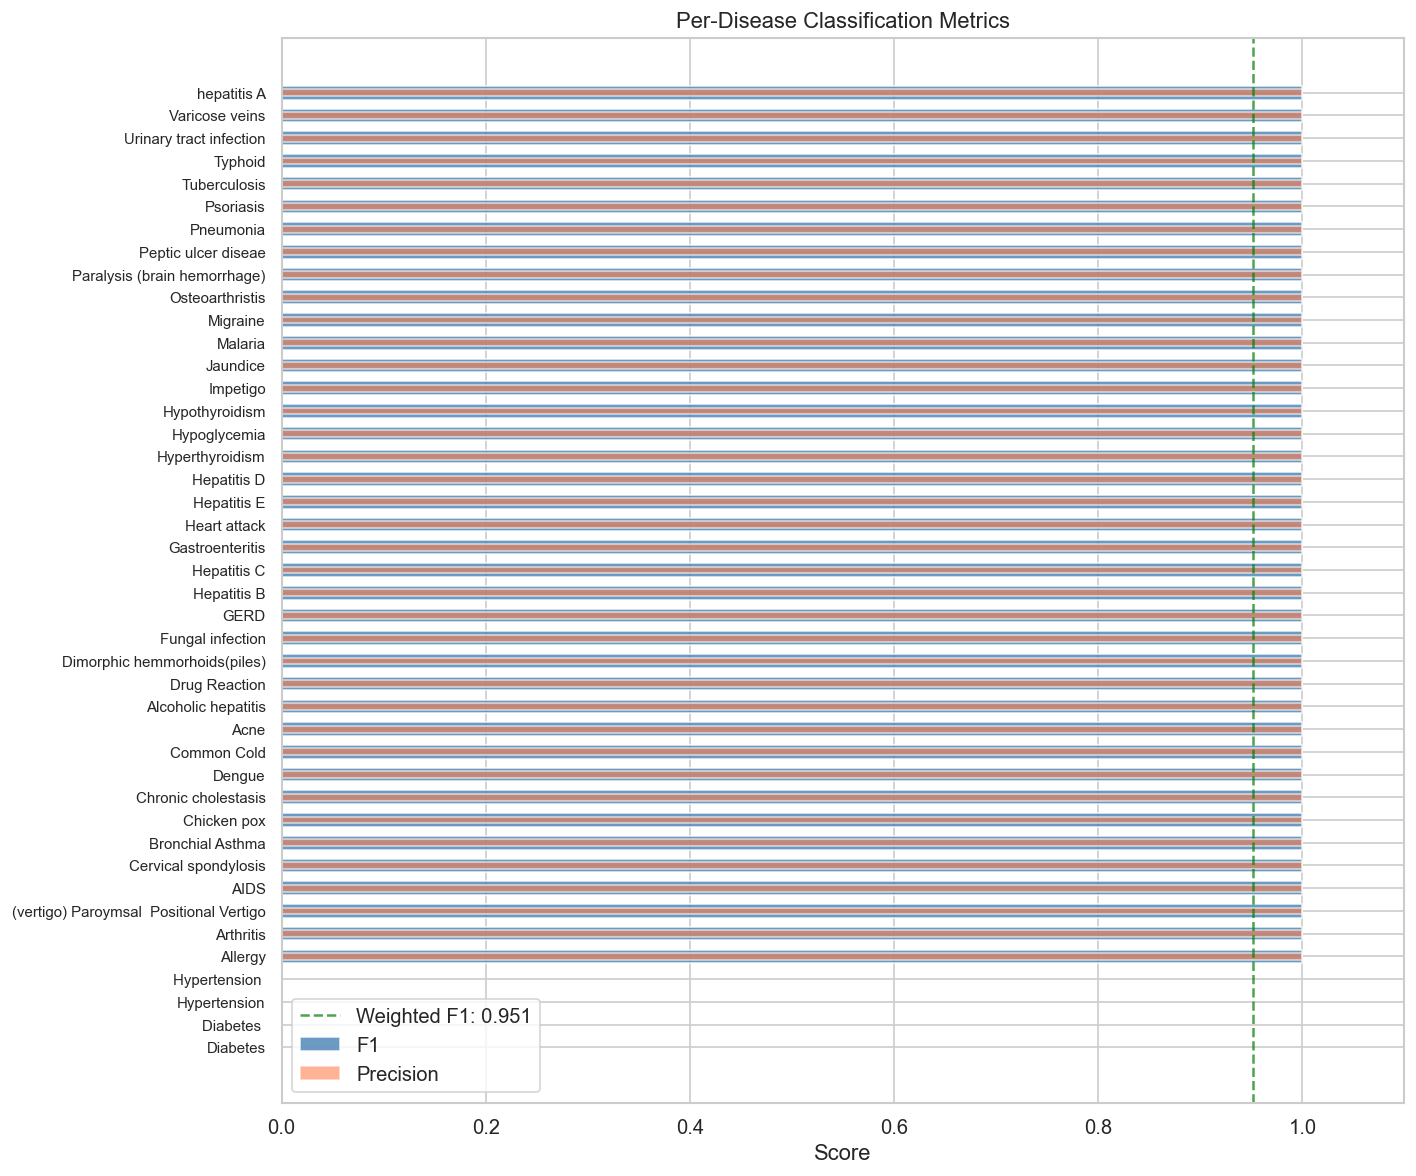


Overall Accuracy: 0.9512
Weighted F1: 0.9512
Macro F1: 0.9070


In [17]:
if has_model:
    # Per-class F1 bar chart
    class_metrics = {k: v for k, v in report.items() 
                     if k not in ('accuracy', 'macro avg', 'weighted avg')}
    
    f1_df = pd.DataFrame([
        {'Disease': k, 'F1': v['f1-score'], 'Precision': v['precision'], 'Recall': v['recall']}
        for k, v in class_metrics.items()
    ]).sort_values('F1', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    y_pos = range(len(f1_df))
    ax.barh(y_pos, f1_df['F1'], height=0.6, color='steelblue', alpha=0.8, label='F1')
    ax.barh(y_pos, f1_df['Precision'], height=0.3, color='coral', alpha=0.6, label='Precision')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(f1_df['Disease'], fontsize=9)
    ax.set_xlabel('Score')
    ax.set_title('Per-Disease Classification Metrics')
    ax.legend()
    ax.set_xlim(0, 1.1)
    ax.axvline(x=report['weighted avg']['f1-score'], color='green', linestyle='--', 
               alpha=0.7, label=f"Weighted F1: {report['weighted avg']['f1-score']:.3f}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(ROOT / 'notebooks' / 'fig_per_class_metrics.png', bbox_inches='tight')
    plt.show()
    
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    print(f"Weighted F1: {report['weighted avg']['f1-score']:.4f}")
    print(f"Macro F1: {report['macro avg']['f1-score']:.4f}")

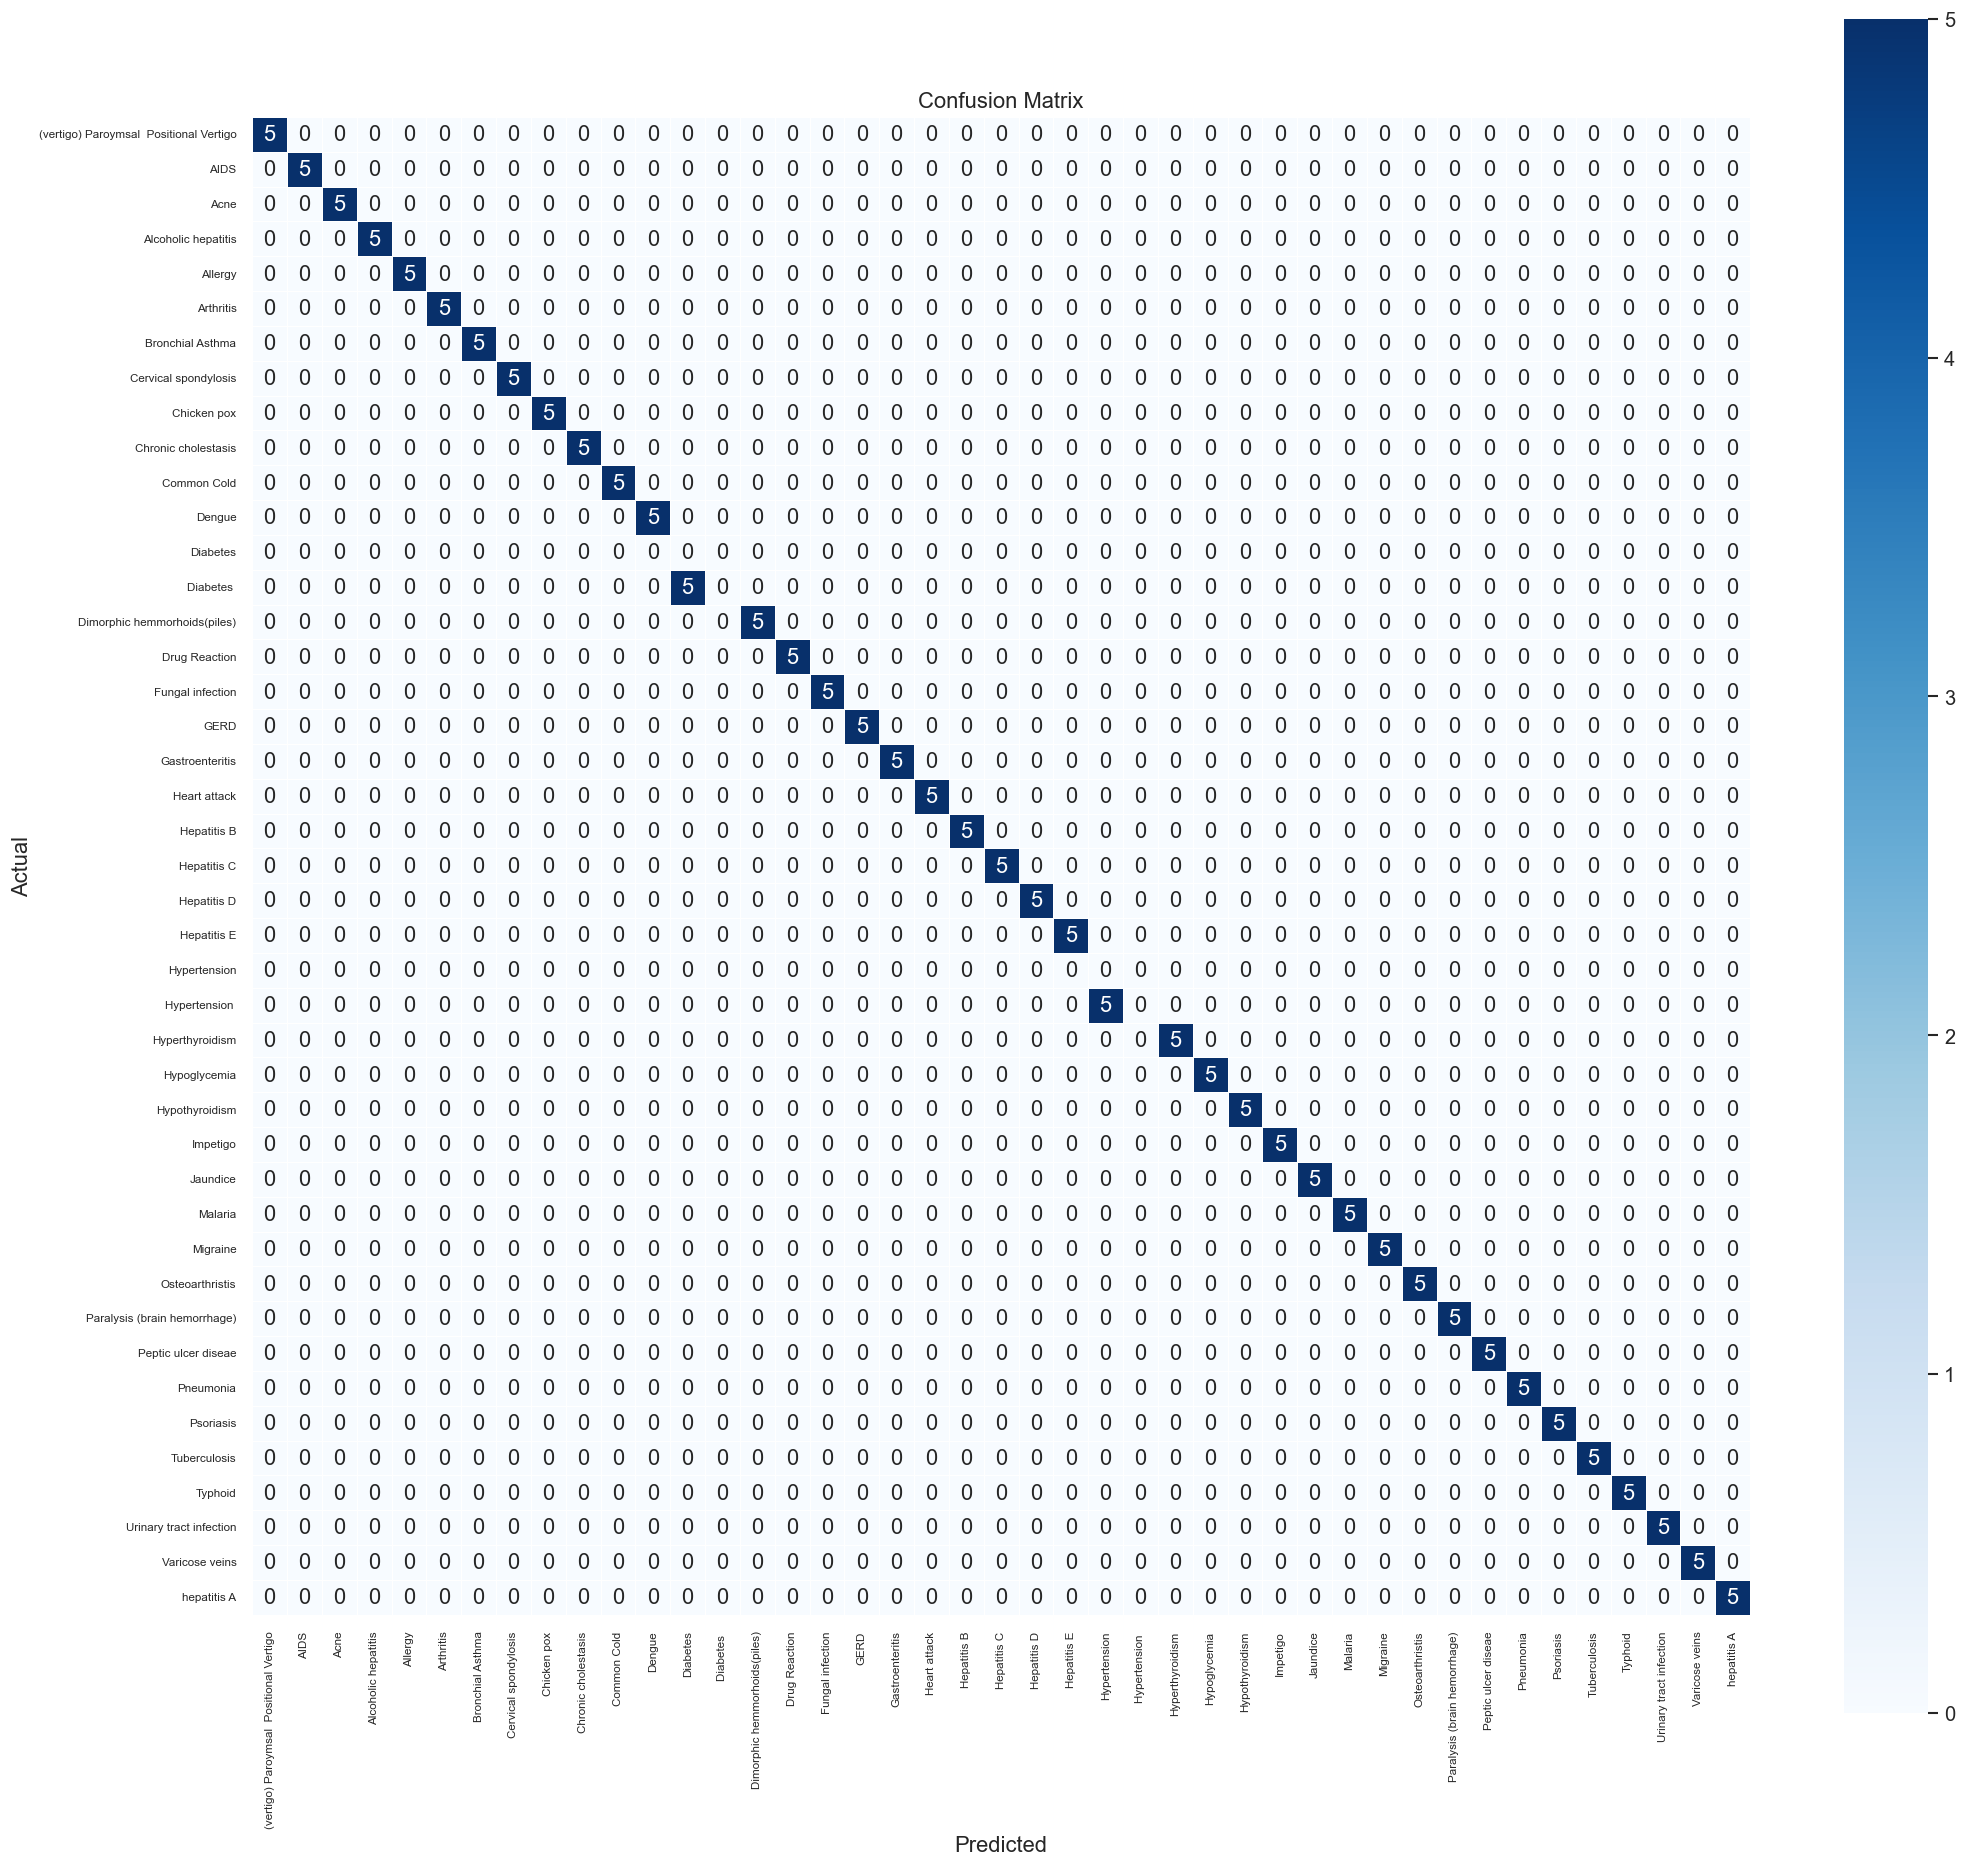

In [18]:
if has_model:
    # Confusion matrix (subset for readability)
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=all_labels, yticklabels=all_labels, ax=ax,
                linewidths=0.5, square=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.savefig(ROOT / 'notebooks' / 'fig_confusion_matrix.png', bbox_inches='tight')
    plt.show()

## 5. Explainability Demo

The system uses SHAP and LIME combined into a single unified importance score.
Here we demonstrate the explainability pipeline on a sample input.

In [20]:
if has_model:
    import sys as _sys, torch as _torch
    # Python 3.14+ does not support torch.compile; patch it to a no-op
    # so that lazy imports inside transformers/SHAP don't crash.
    if _sys.version_info >= (3, 14):
        _torch.compile = lambda fn=None, **kwargs: fn if fn is not None else (lambda f: f)

    import shap
    
    sample_text = "itching, skin_rash, nodal_skin_eruptions, dischromic _patches"
    print(f"Sample input: {sample_text}\n")
    
    # Get prediction
    preds = clf(sample_text)
    if isinstance(preds[0], list):
        preds = preds[0]
    top3 = sorted(preds, key=lambda x: x['score'], reverse=True)[:3]
    
    print("Top 3 Predictions:")
    for p in top3:
        bar = '█' * int(p['score'] * 40)
        print(f"  {p['label']:<40} {p['score']:>6.2%}  {bar}")
    
    # SHAP
    print("\nComputing SHAP values...")
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(clf, masker)
    shap_values = explainer([sample_text])
    
    predicted_label = top3[0]['label']
    class_idx = list(shap_values.output_names).index(predicted_label)
    
    words = shap_values.data[0]
    scores = shap_values.values[0][:, class_idx]
    
    print(f"\nSHAP values for predicted class '{predicted_label}':")
    for w, s in sorted(zip(words, scores), key=lambda x: abs(x[1]), reverse=True):
        if str(w).strip() and str(w) not in ['[CLS]', '[SEP]', '[PAD]']:
            direction = '+' if s > 0 else '-'
            print(f"  {direction} {str(w):<25} {s:>+.4f}")

Sample input: itching, skin_rash, nodal_skin_eruptions, dischromic _patches

Top 3 Predictions:
  Fungal infection                         99.61%  ███████████████████████████████████████
  Drug Reaction                             0.03%  
  Bronchial Asthma                          0.03%  

Computing SHAP values...


PartitionExplainer explainer: 2it [04:04, 244.83s/it]              


SHAP values for predicted class 'Fungal infection':
  + eruption                  +0.2003
  + skin                      +0.1149
  + nod                       +0.0859
  + r                         +0.0751
  + patches                   +0.0704
  + it                        +0.0646
  + hr                        +0.0540
  + al                        +0.0484
  + s                         +0.0460
  + ash                       +0.0460
  + skin                      +0.0450
  + ,                         +0.0319
  + disc                      +0.0263
  + c                         +0.0259
  + ching                     +0.0187
  + ,                         +0.0131
  + ,                         +0.0095
  + _                         +0.0088
  - omi                       -0.0049
  + _                         +0.0042
  + _                         +0.0022
  - _                         -0.0013


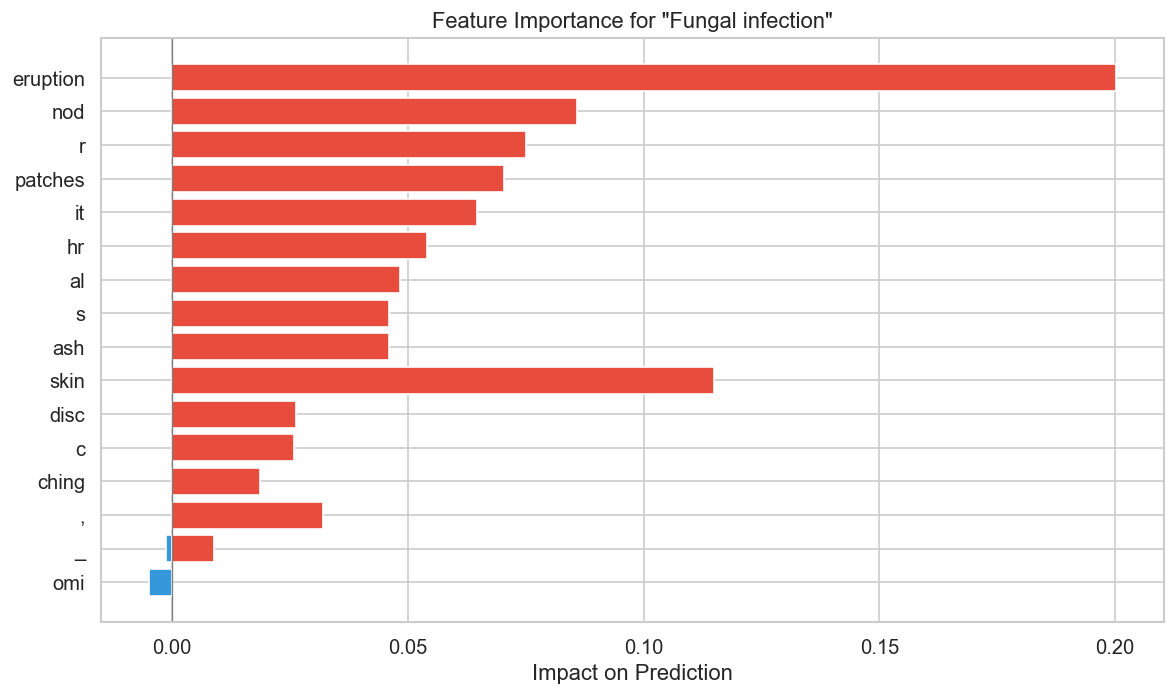

In [21]:
if has_model:
    # Visual SHAP bar chart
    word_scores = []
    for w, s in zip(words, scores):
        w_str = str(w).strip()
        if w_str and w_str not in ['[CLS]', '[SEP]', '[PAD]']:
            word_scores.append((w_str, float(s)))
    
    word_scores.sort(key=lambda x: x[1])
    ws_names, ws_vals = zip(*word_scores)
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in ws_vals]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(ws_names, ws_vals, color=colors)
    ax.set_xlabel('Impact on Prediction')
    ax.set_title(f'Feature Importance for "{predicted_label}"')
    ax.axvline(x=0, color='gray', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(ROOT / 'notebooks' / 'fig_explainability_demo.png', bbox_inches='tight')
    plt.show()

## 6. Symptom Vocabulary Summary

The system uses a structured vocabulary of 131 symptoms extracted from the training data.

In [22]:
vocab_path = BACKEND / 'symptom_vocabulary.json'
if vocab_path.exists():
    with open(vocab_path) as f:
        vocab = json.load(f)
    
    print(f"Symptoms: {len(vocab['symptoms'])}")
    print(f"Diseases: {len(vocab['diseases'])}")
    print(f"Keyword index entries: {len(vocab.get('keyword_index', {}))}")
    
    # Average diseases per symptom
    s2d = vocab['symptom_to_diseases']
    avg = np.mean([len(v) for v in s2d.values()])
    print(f"Avg diseases per symptom: {avg:.1f}")
    
    # Most "specific" symptoms (appear in fewest diseases)
    specificity = sorted(s2d.items(), key=lambda x: len(x[1]))
    print(f"\nMost specific symptoms (fewest diseases):")
    for sym, diseases in specificity[:10]:
        print(f"  {sym.replace('_', ' ').title():<30} → {', '.join(diseases)}")
    
    # Most "generic" symptoms (appear in most diseases)
    print(f"\nMost generic symptoms (most diseases):")
    for sym, diseases in specificity[-10:]:
        print(f"  {sym.replace('_', ' ').title():<30} → {len(diseases)} diseases")
else:
    print("Vocabulary not found. Run scripts/extract_symptoms.py first.")

Symptoms: 131
Diseases: 41
Keyword index entries: 205
Avg diseases per symptom: 2.5

Most specific symptoms (fewest diseases):
  Nodal Skin Eruptions           → Fungal infection
  Dischromic  Patches            → Fungal infection
  Shivering                      → Allergy
  Watering From Eyes             → Allergy
  Ulcers On Tongue               → GERD
  Spotting  Urination            → Drug Reaction
  Passage Of Gases               → Peptic ulcer diseae
  Internal Itching               → Peptic ulcer diseae
  Muscle Wasting                 → AIDS
  Patches In Throat              → AIDS

Most generic symptoms (most diseases):
  Chills                         → 7 diseases
  Yellowing Of Eyes              → 7 diseases
  Yellowish Skin                 → 8 diseases
  Abdominal Pain                 → 9 diseases
  Nausea                         → 10 diseases
  Loss Of Appetite               → 10 diseases
  Headache                       → 10 diseases
  High Fever                     → 12 d

---

## Summary

This notebook demonstrated the full pipeline of the disease prediction system:

- **Dataset**: 4,920 rows, 41 diseases, 131 unique symptoms from `DiseaseAndSymptoms.csv`
- **Model**: Bio_ClinicalBERT fine-tuned with 8x data augmentation for robustness
- **Explainability**: SHAP + LIME merged into a single unified importance score
- **Precautions**: Real medical advice loaded from `Disease precaution.csv`
- **Input**: Searchable multi-select dropdown (131 symptoms) + optional free text

The system architecture ensures the model always receives normalised input that matches
its training distribution, solving the key mismatch between free-text input and structured
training data.